In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

In [9]:
DATASET_PATH = "/content/drive/MyDrive/banana_leaf_disease"

In [10]:
IMG_SIZE = 224

images = []
labels = []

class_names = sorted(os.listdir(DATASET_PATH))

print("Classes:", class_names)

for label, class_name in enumerate(class_names):

    folder = os.path.join(DATASET_PATH, class_name)

    for image_name in os.listdir(folder):

        image_path = os.path.join(folder, image_name)

        try:
            image = cv2.imread(image_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

            images.append(image)
            labels.append(label)

        except:
            pass

X = np.array(images, dtype=np.float32)
y = np.array(labels)

print("X Shape :", X.shape)
print("y Shape :", y.shape)

Classes: ['PESTAL~1', 'cordana', 'healthy', 'sigatoka']
X Shape : (1600, 224, 224, 3)
y Shape : (1600,)


In [11]:
X = preprocess_input(X)

In [12]:
print(X.min())
print(X.max())

0.0
255.0


In [13]:
from collections import Counter

print(Counter(y))

Counter({np.int64(0): 400, np.int64(1): 400, np.int64(2): 400, np.int64(3): 400})


In [14]:
def cbam_block(feature_map, ratio=8):

    channel = feature_map.shape[-1]

    avg_pool = layers.GlobalAveragePooling2D()(feature_map)
    avg_pool = layers.Reshape((1,1,channel))(avg_pool)

    max_pool = layers.GlobalMaxPooling2D()(feature_map)
    max_pool = layers.Reshape((1,1,channel))(max_pool)

    shared_dense_1 = layers.Dense(
        channel // ratio,
        activation='relu'
    )

    shared_dense_2 = layers.Dense(channel)

    avg_out = shared_dense_2(shared_dense_1(avg_pool))
    max_out = shared_dense_2(shared_dense_1(max_pool))

    channel_attention = layers.Add()([avg_out, max_out])
    channel_attention = layers.Activation('sigmoid')(channel_attention)

    feature_map = layers.Multiply()(
        [feature_map, channel_attention]
    )

    avg_pool = layers.Lambda(
        lambda x: tf.reduce_mean(
            x,
            axis=-1,
            keepdims=True
        )
    )(feature_map)

    max_pool = layers.Lambda(
        lambda x: tf.reduce_max(
            x,
            axis=-1,
            keepdims=True
        )
    )(feature_map)

    concat = layers.Concatenate(axis=-1)(
        [avg_pool, max_pool]
    )

    spatial_attention = layers.Conv2D(
        filters=1,
        kernel_size=7,
        padding="same",
        activation="sigmoid"
    )(concat)

    feature_map = layers.Multiply()(
        [feature_map, spatial_attention]
    )

    return feature_map

In [15]:
def create_model():

    base_model = MobileNetV3Large(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )

    base_model.trainable = True

    for layer in base_model.layers[:-60]:
        layer.trainable = False


    inputs = layers.Input(shape=(224,224,3))

    x = base_model(inputs)

    x = cbam_block(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
        len(class_names),
        activation='softmax'
    )(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-5
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [16]:
from sklearn.model_selection import StratifiedKFold

In [17]:
print(type(X))
print(type(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [18]:
kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_accuracies = []

all_true = []
all_pred = []

fold_no = 1

In [19]:
for train_idx, val_idx in kfold.split(X, y):

    print("\n")
    print("=" * 50)
    print(f"Fold {fold_no}")
    print("=" * 50)

    X_train = X[train_idx]
    X_val = X[val_idx]

    y_train = y[train_idx]
    y_val = y[val_idx]

    model = create_model()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        verbose=1
    )

    loss, accuracy = model.evaluate(
        X_val,
        y_val,
        verbose=0
    )

    print(f"Fold {fold_no} Accuracy: {accuracy * 100:.2f}%")

    fold_accuracies.append(accuracy * 100)

    predictions = model.predict(X_val)

    predictions = np.argmax(predictions, axis=1)

    all_true.extend(y_val)
    all_pred.extend(predictions)

    fold_no += 1



Fold 1
Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 46s 206ms/step - accuracy: 0.2664 - loss: 1.4920 - val_accuracy: 0.3000 - val_loss: 1.5071
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.3562 - loss: 1.3378 - val_accuracy: 0.3313 - val_loss: 1.4073
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.4695 - loss: 1.2100 - val_accuracy: 0.3719 - val_loss: 1.3202
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5508 - loss: 1.0978 - val_accuracy: 0.4125 - val_loss: 1.2346
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.6297 - loss: 0.9954 - val_accuracy: 0.4844 - val_loss: 1.1513
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7250 - loss: 0.8785 - val_accuracy: 0.5188 - val_loss: 1.0708
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7461 - loss: 0.8066 - val_accuracy: 0.5656 - val_loss: 0.9966
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.8023 - loss: 0.7190 - val_accuracy:

In [20]:
print("\nCross Validation Results")

for i, acc in enumerate(fold_accuracies):
    print(f"Fold {i+1}: {acc:.2f}%")

print("\nMean Accuracy:")
print(np.mean(fold_accuracies))

print("\nStandard Deviation:")
print(np.std(fold_accuracies))


Cross Validation Results
Fold 1: 93.44%
Fold 2: 98.12%
Fold 3: 99.06%
Fold 4: 81.25%
Fold 5: 95.63%

Mean Accuracy:
93.50000023841858

Standard Deviation:
6.432947741317719


<Figure size 800x800 with 0 Axes>

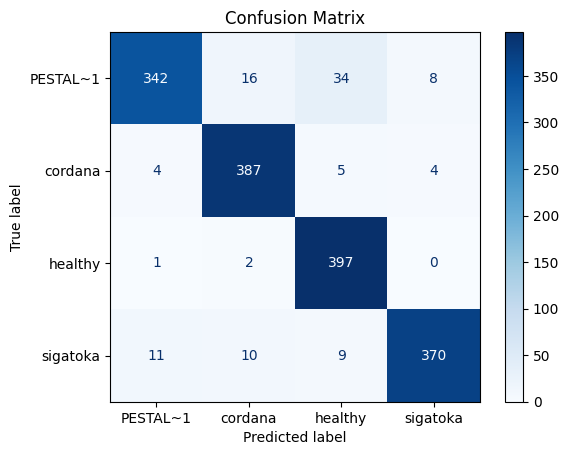

In [21]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    all_true,
    all_pred
)

plt.figure(figsize=(8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [22]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_true,
        all_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    PESTAL~1       0.96      0.85      0.90       400
     cordana       0.93      0.97      0.95       400
     healthy       0.89      0.99      0.94       400
    sigatoka       0.97      0.93      0.95       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.93      1600
weighted avg       0.94      0.94      0.93      1600



In [23]:
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1)
])

In [25]:
def create_model():

    base_model = MobileNetV3Large(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )

    base_model.trainable = True

    for layer in base_model.layers[:-80]:
        layer.trainable = False


    data_aug = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.1)
    ])


    inputs = layers.Input(shape=(224,224,3))

    x = data_aug(inputs)   # ✅ augmentation happens here
    x = base_model(x)

In [26]:
model.save("mobilenetv3_cbam_banana_model.keras")

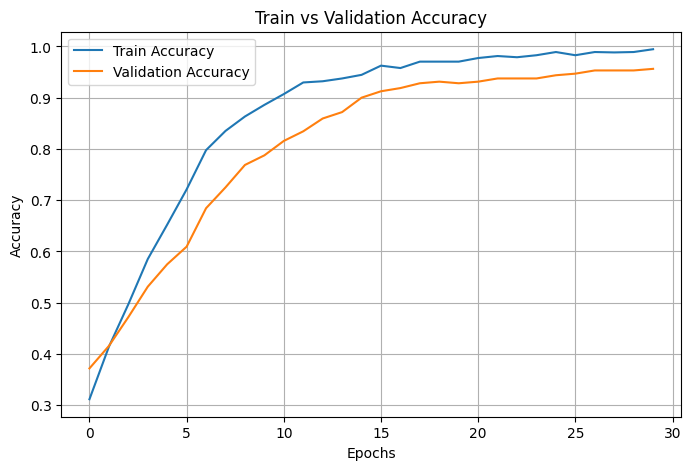

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Train vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

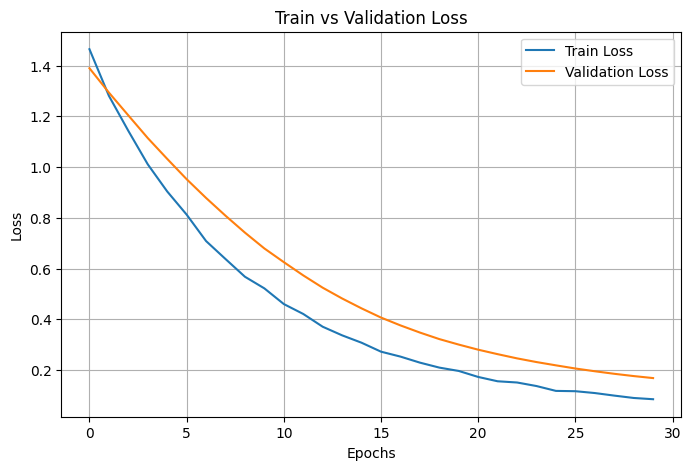

In [28]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Train vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [29]:
print("\nFINAL MODEL SUMMARY")
print("="*40)

print("Mean Cross Validation Accuracy :", np.mean(fold_accuracies))
print("Standard Deviation             :", np.std(fold_accuracies))

print("\nFinal Fold Accuracy Breakdown:")
for i, acc in enumerate(fold_accuracies):
    print(f"Fold {i+1}: {acc:.2f}%")


FINAL MODEL SUMMARY
Mean Cross Validation Accuracy : 93.50000023841858
Standard Deviation             : 6.432947741317719

Final Fold Accuracy Breakdown:
Fold 1: 93.44%
Fold 2: 98.12%
Fold 3: 99.06%
Fold 4: 81.25%
Fold 5: 95.63%


In [30]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_image(img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)

    img = preprocess_input(img)

    pred = model.predict(img)
    class_index = np.argmax(pred)

    print("Predicted Class:", class_names[class_index])

In [31]:
predict_image("/content/drive/MyDrive/banana_leaf_disease/PESTAL~1/104.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step
Predicted Class: PESTAL~1


In [32]:
def create_model():

    # ---------------- BACKBONE ----------------
    base_model = MobileNetV3Large(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )

    base_model.trainable = True

    # Fine-tuning (better than -60)
    for layer in base_model.layers[:-80]:
        layer.trainable = False


    # ---------------- AUGMENTATION ----------------
    data_aug = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ])


    # ---------------- INPUT ----------------
    inputs = layers.Input(shape=(224,224,3))

    x = data_aug(inputs)
    x = base_model(x)

    x = cbam_block(x)

    x = layers.GlobalAveragePooling2D()(x)

    # ---------------- REGULARIZATION ----------------
    x = layers.Dropout(0.5)(x)
    x = layers.BatchNormalization()(x)

    # ---------------- OUTPUT ----------------
    outputs = layers.Dense(
        len(class_names),
        activation='softmax'
    )(x)

    model = Model(inputs, outputs)

    # ---------------- COMPILATION ----------------
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=3e-5
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(
            label_smoothing=0.1
        ),
        metrics=['accuracy']
    )

    return model

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)

print("Validation Accuracy:", accuracy * 100)


Validation Accuracy: 97.81249761581421


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


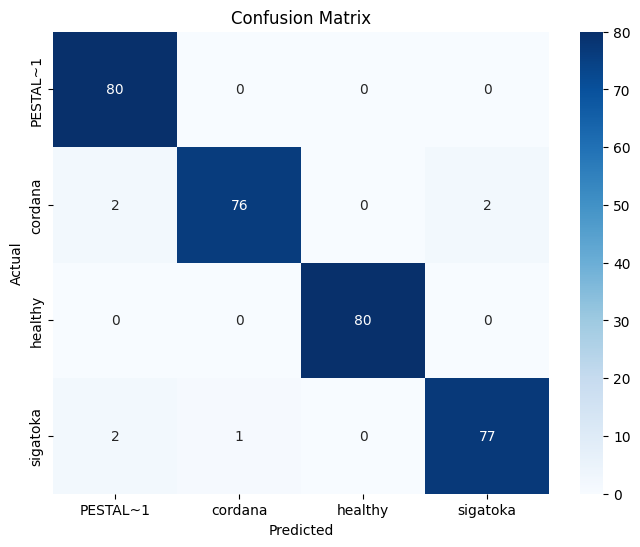

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the validation set
predictions = model.predict(X_val)
y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(
    y_val,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [38]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    PESTAL~1       0.95      1.00      0.98        80
     cordana       0.99      0.95      0.97        80
     healthy       1.00      1.00      1.00        80
    sigatoka       0.97      0.96      0.97        80

    accuracy                           0.98       320
   macro avg       0.98      0.98      0.98       320
weighted avg       0.98      0.98      0.98       320



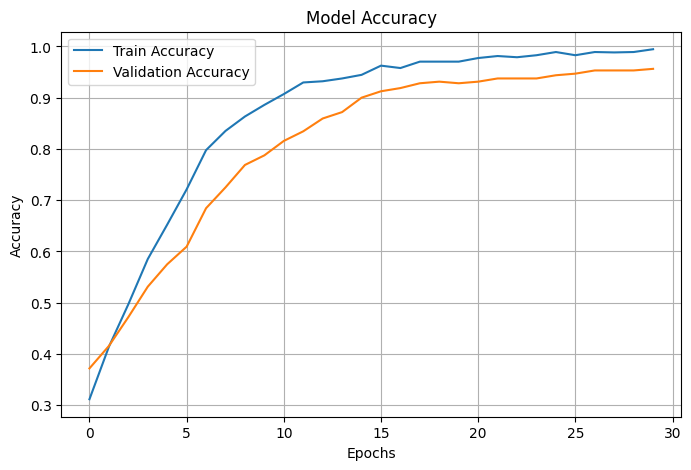

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

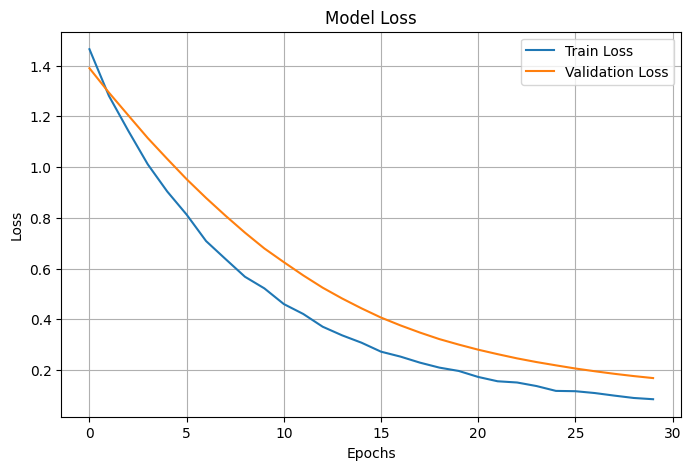

In [40]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [41]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

gap = train_acc - val_acc

print("FINAL ACCURACY SUMMARY")
print("="*30)

print(f"Train Accuracy      : {train_acc*100:.2f}%")
print(f"Validation Accuracy : {val_acc*100:.2f}%")
print(f"Accuracy Gap        : {gap*100:.2f}%")

FINAL ACCURACY SUMMARY
Train Accuracy      : 99.45%
Validation Accuracy : 95.63%
Accuracy Gap        : 3.83%


In [42]:
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

loss_gap = val_loss - train_loss

print("\nLOSS SUMMARY")
print("="*30)

print(f"Train Loss      : {train_loss:.4f}")
print(f"Validation Loss : {val_loss:.4f}")
print(f"Loss Gap        : {loss_gap:.4f}")


LOSS SUMMARY
Train Loss      : 0.0847
Validation Loss : 0.1680
Loss Gap        : 0.0834


In [43]:
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_val_acc = max(history.history['val_accuracy'])

print("\nBEST PERFORMANCE")
print("="*30)

print(f"Best Epoch              : {best_epoch}")
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}%")


BEST PERFORMANCE
Best Epoch              : 30
Best Validation Accuracy: 95.63%


In [47]:
def create_model():

    base_model = MobileNetV3Large(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )

    # 🔥 Strong freeze (prevents overfitting)
    base_model.trainable = True
    for layer in base_model.layers[:-120]:
        layer.trainable = False


    # 🔥 Strong augmentation (on-the-fly only)
    data_aug = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.2),
    ])


    inputs = layers.Input(shape=(224,224,3))
    x = data_aug(inputs)

    x = base_model(x)

    # ❗ CBAM OPTIONAL (keep for now, but safe version)
    x = cbam_block(x)

    x = layers.GlobalAveragePooling2D()(x)

    # 🔥 Strong regularization head
    x = layers.Dense(
        256,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.01)
    )(x)

    x = layers.Dropout(0.6)(x)

    outputs = layers.Dense(
        len(class_names),
        activation='softmax'
    )(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-5
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(), # Removed label_smoothing
        metrics=['accuracy']
    )

    return model

In [48]:
model = create_model()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 36s 211ms/step - accuracy: 0.2867 - loss: 5.4272 - val_accuracy: 0.2531 - val_loss: 5.4145
Epoch 2/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 0.2812 - loss: 5.3819 - val_accuracy: 0.3063 - val_loss: 5.3659
Epoch 3/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.3250 - loss: 5.3237 - val_accuracy: 0.3313 - val_loss: 5.3184
Epoch 4/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 145ms/step - accuracy: 0.3219 - loss: 5.2768 - val_accuracy: 0.3688 - val_loss: 5.2705
Epoch 5/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 148ms/step - accuracy: 0.3570 - loss: 5.2333 - val_accuracy: 0.3938 - val_loss: 5.2222
Epoch 6/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 150ms/step - accuracy: 0.3961 - loss: 5.1730 - val_accuracy: 0.4313 - val_loss: 5.1728
Epoch 7/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 144ms/step - accuracy: 0.4242 - loss: 5.1139 - val_accuracy: 0.4688 - val_loss: 5.1225
Epoch 8/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 191ms/step - accuracy: 0.4391 - loss: 5.0631 - val_accuracy:

In [49]:
loss, acc = model.evaluate(X_val, y_val, verbose=0)

print("Validation Accuracy:", acc * 100)

Validation Accuracy: 97.1875011920929


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step


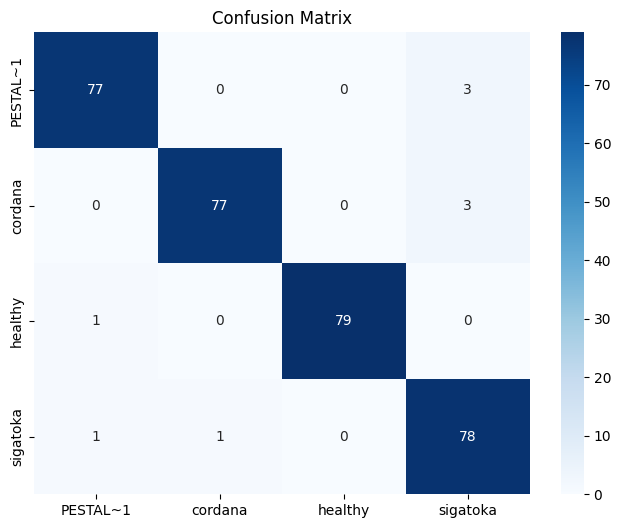

In [50]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_val)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.show()

In [52]:
train_acc = max(history.history['accuracy'])
val_acc = max(history.history['val_accuracy'])

gap = train_acc - val_acc

print("\nFINAL OVERFITTING REPORT")
print("="*30)
print(f"Train Accuracy : {train_acc*100:.2f}%")
print(f"Val Accuracy   : {val_acc*100:.2f}%")
print(f"Gap            : {gap*100:.2f}%")



FINAL OVERFITTING REPORT
Train Accuracy : 95.16%
Val Accuracy   : 97.19%
Gap            : -2.03%


In [53]:
def create_model():

    # ---------------- BACKBONE ----------------
    base_model = MobileNetV3Large(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )

    base_model.trainable = True

    # Slightly stronger freezing (reduces overfitting)
    for layer in base_model.layers[:-130]:
        layer.trainable = False


    # ---------------- AUGMENTATION ----------------
    data_aug = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.2),
    ])


    # ---------------- INPUT ----------------
    inputs = layers.Input(shape=(224,224,3))

    x = data_aug(inputs)

    x = base_model(x)

    x = cbam_block(x)

    x = layers.GlobalAveragePooling2D()(x)

    # ---------------- REGULARIZATION ----------------
    x = layers.Dense(
        256,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.01)
    )(x)

    x = layers.Dropout(0.65)(x)

    x = layers.BatchNormalization()(x)

    # ---------------- OUTPUT ----------------
    outputs = layers.Dense(
        len(class_names),
        activation='softmax'
    )(x)

    model = Model(inputs, outputs)

    # ---------------- COMPILATION ----------------
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=8e-6
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [54]:
train_acc = max(history.history['accuracy'])
val_acc = max(history.history['val_accuracy'])

gap = train_acc - val_acc

print("\nFINAL OVERFITTING REPORT")
print("="*30)
print(f"Train Accuracy : {train_acc*100:.2f}%")
print(f"Val Accuracy   : {val_acc*100:.2f}%")
print(f"Gap            : {gap*100:.2f}%")


FINAL OVERFITTING REPORT
Train Accuracy : 95.16%
Val Accuracy   : 97.19%
Gap            : -2.03%


In [55]:
def create_model():

    # ---------------- BACKBONE ----------------
    base_model = MobileNetV3Large(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )

    base_model.trainable = True

    # Strong freeze for stability
    for layer in base_model.layers[:-130]:
        layer.trainable = False


    # ---------------- AUGMENTATION (STRONGER) ----------------
    data_aug = tf.keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
        layers.RandomContrast(0.3),
        layers.RandomTranslation(0.1, 0.1)
    ])


    # ---------------- INPUT ----------------
    inputs = layers.Input(shape=(224,224,3))

    x = data_aug(inputs)

    x = base_model(x)

    # ❗ CBAM REMOVED (best for reducing overfitting test)
    # x = cbam_block(x)

    x = layers.GlobalAveragePooling2D()(x)

    # ---------------- CLASSIFIER HEAD ----------------
    x = layers.Dense(
        256,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.01)
    )(x)

    x = layers.Dropout(0.5)(x)

    x = layers.BatchNormalization()(x)

    # ---------------- OUTPUT ----------------
    outputs = layers.Dense(
        len(class_names),
        activation='softmax'
    )(x)

    model = Model(inputs, outputs)

    # ---------------- OPTIMIZER + LOSS ----------------
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=8e-6,
            weight_decay=1e-4
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [56]:
train_acc = max(history.history['accuracy'])
val_acc = max(history.history['val_accuracy'])

gap = train_acc - val_acc

print("\nFINAL OVERFITTING REPORT")
print("="*30)
print(f"Train Accuracy : {train_acc*100:.2f}%")
print(f"Val Accuracy   : {val_acc*100:.2f}%")
print(f"Gap            : {gap*100:.2f}%")


FINAL OVERFITTING REPORT
Train Accuracy : 95.16%
Val Accuracy   : 97.19%
Gap            : -2.03%


In [70]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / tf.reduce_max(heatmap)

    return heatmap.numpy()

In [71]:
def show_gradcam(img_path, model, class_names, last_conv_layer_name):

    import cv2
    import numpy as np
    import matplotlib.pyplot as plt

    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = tf.keras.applications.mobilenet_v3.preprocess_input(img_array)

    preds = model.predict(img_array)
    pred_class = np.argmax(preds[0])

    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Predicted: {class_names[pred_class]}")
    plt.axis("off")

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_1820']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


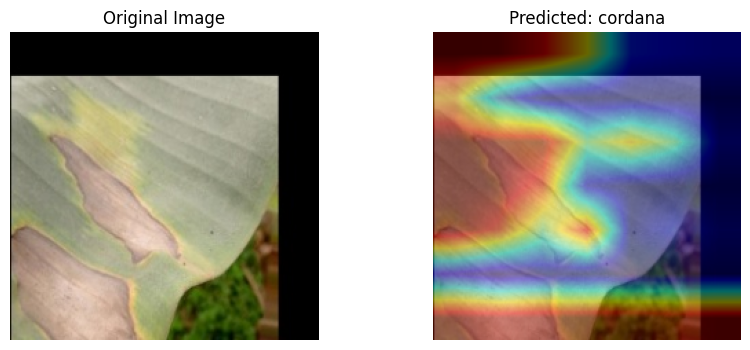

In [72]:
last_conv_layer_name = "conv2d_7"

show_gradcam(
    "/content/drive/MyDrive/banana_leaf_disease/cordana/115.jpeg",
    model,
    class_names,
    last_conv_layer_name
)